In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [38]:
df = pd.read_csv('data/raw/hotel_bookings_raw.csv')
print(f"Total Records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Total Records: 12360
Columns: ['booking_id', 'hotel_name', 'category', 'price', 'rating', 'country', 'created_date', 'rooms_booked', 'customer_email']


In [39]:
df.head(10)

,booking_id,hotel_name,category,price,rating,country,created_date,rooms_booked,customer_email
0,9521,Miller and Sons Hotel,Luxury,443.71,4.6,France,2025-11-29,4.0,brandywhite@example.com
1,11157,Carroll PLC Hotel,Family,156.19,3.8,Thailand,2025-12-07,1.0,tonya99@example.com
2,8881,Wiley-Pacheco Hotel,Boutique,351.72,4.2,Italy,05/09/2025,1.0,yrussell@example.net
3,5874,Coleman PLC Hotel,Family,78.43,4.2,Japan,2025-03-13,1.0,PPATEL@EXAMPLE.NET
4,12421,Schwartz-Carter Hotel,Budget,78.27,4.7,Japan,08/06/2024,3.0,LISA05@EXAMPLE.NET
5,8745,Peck Group Hotel,boutique,170.29,4.7,UK,2025-01-30,1.0,THOMAS90@EXAMPLE.COM
6,4692,Griffin-Cohen Hotel,Luxury,411.49,3.4,USA,2025-12-11,3.0,wattsemma@example.net
7,2496,Bailey Ltd Hotel,Budget,157.11,4.2,Singapore,2024-05-30,1.0,LPALMER@EXAMPLE.NET
8,2213,Bird-Savage Hotel,resort,309.50,3.3,France,2025-04-03,5.0,nsims@example.org
9,6464,Carroll-Barnes Hotel,family,108.91,4.9,Italy,25/01/2026,2.0,susanjones@example.com


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   booking_id      12360 non-null  int64  
 1   hotel_name      12360 non-null  str    
 2   category        12360 non-null  str    
 3   price           11417 non-null  float64
 4   rating          11748 non-null  float64
 5   country         12360 non-null  str    
 6   created_date    12360 non-null  str    
 7   rooms_booked    12015 non-null  float64
 8   customer_email  12360 non-null  str    
dtypes: float64(3), int64(1), str(5)
memory usage: 869.2 KB


In [41]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Percentage': missing_percent.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("\nMissing Values Summary:")
print(missing_df)


Missing Values Summary:
         Column  Missing Count  Percentage
3         price            943    7.629450
4        rating            612    4.951456
7  rooms_booked            345    2.791262


<Figure size 1000x600 with 0 Axes>

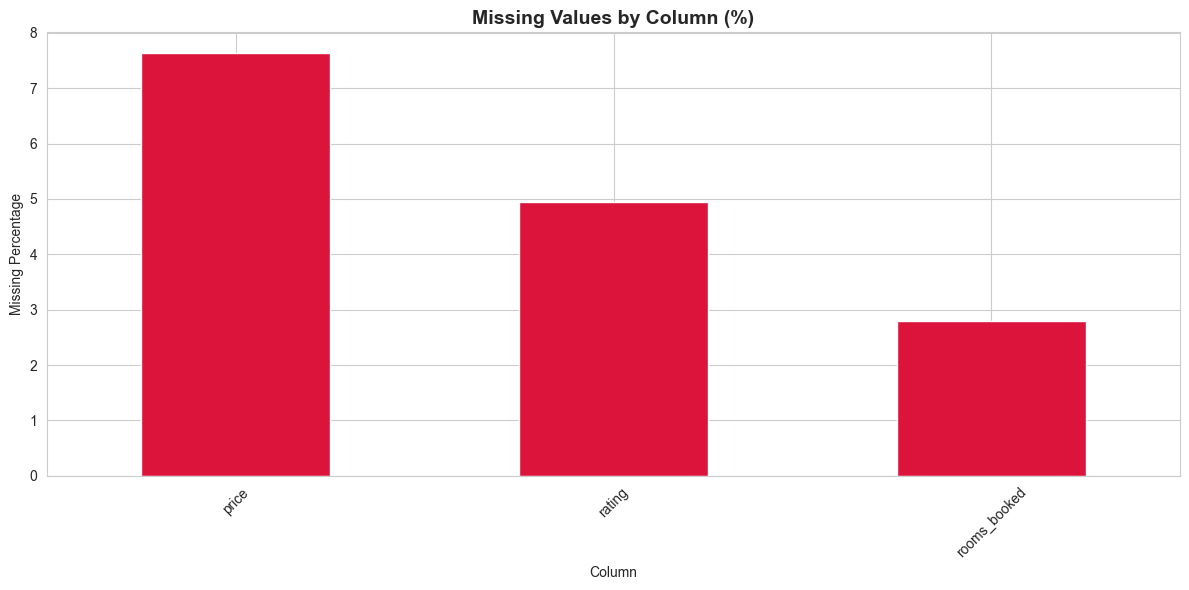

In [42]:
plt.figure(figsize=(10, 6))
missing_df.plot(x='Column', y='Percentage', kind='bar', color='crimson', legend=False)
plt.title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
plt.xlabel('Column')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
duplicate_count = df.duplicated(subset=['booking_id']).sum()
print(f"\nDuplicate booking_id records: {duplicate_count}")
print(f"Percentage: {(duplicate_count/len(df)*100):.2f}%")


Duplicate booking_id records: 360
Percentage: 2.91%


In [44]:
date_formats = df['created_date'].apply(lambda x: 'YYYY-MM-DD' if '-' in str(x) and str(x).count('-') == 2 and str(x)[0].isdigit() and len(str(x).split('-')[0]) == 4
                                         else 'DD/MM/YYYY' if '/' in str(x) and str(x).count('/') == 2
                                         else 'YYYY.MM.DD' if '.' in str(x)
                                         else 'Other')

print("\nDate Format Distribution:")
print(date_formats.value_counts())
print(f"\nUnique date formats found: {date_formats.nunique()}")


Date Format Distribution:
created_date
YYYY-MM-DD    9451
DD/MM/YYYY    1840
YYYY.MM.DD    1069
Name: count, dtype: int64

Unique date formats found: 3


In [45]:
print("\nEmail casing issues:")
uppercase_emails = df['customer_email'].str.isupper().sum()
lowercase_emails = df['customer_email'].str.islower().sum()
mixed_emails = len(df) - uppercase_emails - lowercase_emails

print(f"Uppercase emails: {uppercase_emails}")
print(f"Lowercase emails: {lowercase_emails}")



Email casing issues:
Uppercase emails: 3716
Lowercase emails: 8644


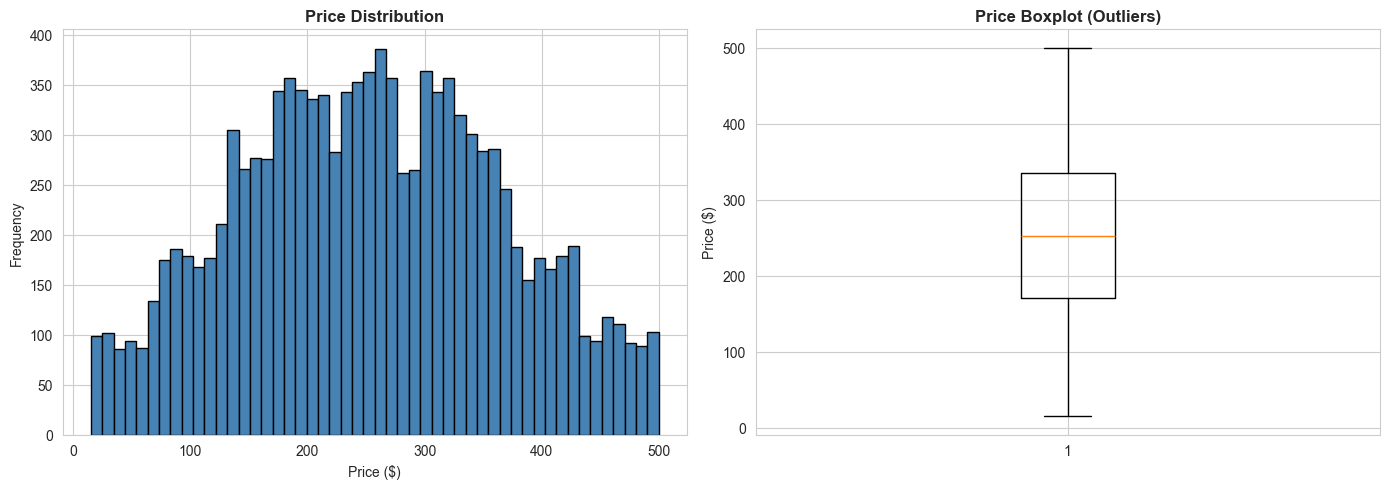

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['price'].dropna())
axes[1].set_title('Price Boxplot (Outliers)', fontweight='bold')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()